[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MaxMitre/Mate_MercadosFinancieros/blob/main/Semana11_Teoria_Valores_Extremos.ipynb)

# Teoría de Valores Extremos (Peaks Over Treshold - POT)


# Dependencias

In [ ]:
import pandas as pd
import numpy as np
from scipy.optimize import minimize

import yfinance as yf

from statsmodels.distributions.empirical_distribution import ECDF
import matplotlib.pyplot as plt

# Idea general:

Lo datos pueden tener valores extremos, ¿como podemos modelarlos?

Comencemos definiendo un umbral a partir del cual consideraremos valores extremos y despues calcular una distribución de probabilidad para estos eventos

![pot[1].png](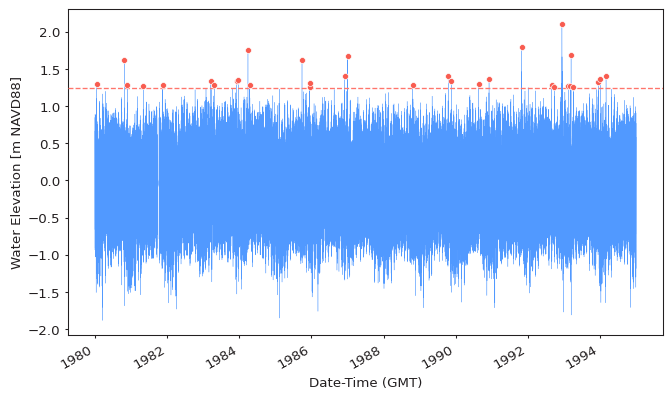)

# Clase mas importante

In [ ]:
class gpd_pot():
    """

    """
    fit = ["mle", "mom", "pwm"]

    def __init__(self, data, tu, fit):
        self.data = data
        self.n = len(data)
        self.u = sorted(data)[int(self.n * tu)]
        self.values = (data.loc[data >= self.u]-self.u).values
        self.n_u = len(self.values)

        def fit_mle(self):

            def log_likelihood(param):
                log_l = -self.n_u*np.log(param[1]) - (1/param[0] + 1 )*sum([ np.log( 1 + (param[0]/param[1])*i) for i in self.values ])
                return -log_l

            bounds_param = ((0+1e-6,None), (0+1e-6,None))
            theta_start = (np.array(0), np.array(1))

            opti_method = 'L-BFGS-B'
            results = minimize(log_likelihood, theta_start, method=opti_method, bounds=bounds_param) #options={'maxiter': 300})#.x[0]
            Beta = results.x[1]
            Xi = results.x[0]

            return Beta, Xi

        def fit_mom(self):
            a0 = self.values.mean()
            a1 = sum([i**2 for i in self.values])/len(self.values)
            Beta = (a0*a1)/(2*a1-2*a0**2)
            Xi = 0.5-(a0**2/(2*a1-2*a0**2))
            return Beta, Xi

        def fit_pwm(self):
            w0 = self.values.mean()
            w1 = sum([ (1- (sorted(self.values).index(x)-0.35)/len(self.values) )*x for x in sorted(self.values)])/len(self.values)
            Beta = (2*w0*w1)/(w0-2*w1)
            Xi = 2-(w0/(w0-2*w1))
            return Beta, Xi

        if fit == "mle":
            self.Beta, self.Xi = fit_mle(self)
        elif fit == "mom":
            self.Beta, self.Xi = fit_mom(self)
        elif fit == "pwm":
            self.Beta, self.Xi = fit_pwm(self)

    def quantile(self, q):
        return  (self.Beta/self.Xi)*( ((1-q) )**(-self.Xi) -1  )

    def varq(self, q):
        return  self.u+(self.Beta/self.Xi)*(((self.n/self.n_u)*(1-q))**(-self.Xi)-1)

    def esq(self, q):
        return (self.u+(self.Beta/self.Xi)*(((self.n/self.n_u)*(1-q))**(-self.Xi)-1))/(1-self.Xi)+(self.Beta-self.Xi*self.u)/(1-self.Xi)

    def qq_plot(self):
        ecdf = ECDF(self.values)
        observed_quantiles = sorted(self.values)
        theorical_quantiles = [self.quantile(q=ecdf(x)) for x in observed_quantiles]

        x = np.linspace(min(self.values), max(self.values), 10)
        plt.plot(x, x, '-', color='red')
        plt.plot(observed_quantiles, theorical_quantiles, '.', color='black')
        plt.show()

    def CDF(self, x):
        if self.Xi ==0:
            return 1-np.exp(-x/self.Beta)
        else:
            return 1-(1+(self.Xi/self.Beta)*x)**(-1/self.Xi)

    def pp_plot(self):
        ecdf = ECDF(self.values)
        observed_cdf = [ecdf(x) for x in sorted(self.values)]
        theorical_cdf = [self.CDF(x) for x in sorted(self.values)]

        x = np.linspace(0, 1, 10)
        plt.plot(x, x, '-', color='red')
        plt.plot(observed_cdf, theorical_cdf, '.', color='black')
        plt.show()

# Explorando 3 funciones que se ejecutan cuando se crea el objeto de clase "gdp_pot"


In [ ]:
df = yf.download(  # or pdr.get_data_yahoo(...
        # tickers list or string as well
        tickers = ["BTC-USD", 'GOOGL'],

        # use "period" instead of start/end
        # valid periods: 1d,5d,1mo,3mo,6mo,1y,2y,5y,10y,ytd,max
        # (optional, default is '1mo')
        period = "1y",

        # fetch data by interval (including intraday if period < 60 days)
        # valid intervals: 1m,2m,5m,15m,30m,60m,90m,1h,1d,5d,1wk,1mo,3mo
        # (optional, default is '1d')
        interval = "1d",

        # group by ticker (to access via data['SPY'])
        # (optional, default is 'column')
        # group_by = 'ticker',
    ).loc[:, 'Adj Close']


[*********************100%***********************]  2 of 2 completed


In [ ]:
df.head()

Ticker,BTC-USD,GOOGL
Date,,
2023-10-10 00:00:00+00:00,27391.019531,NaN
2023-10-11 00:00:00+00:00,26873.320312,140.202850
2023-10-12 00:00:00+00:00,26756.798828,138.626740
2023-10-13 00:00:00+00:00,26862.375000,137.020706
2023-10-14 00:00:00+00:00,26861.707031,NaN


In [ ]:
df.shape

(367, 2)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 367 entries, 2023-10-10 00:00:00+00:00 to 2024-10-10 00:00:00+00:00
Freq: D
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   BTC-USD  367 non-null    float64
 1   GOOGL    252 non-null    float64
dtypes: float64(2)
memory usage: 8.6 KB


In [ ]:
df.dropna(inplace=True)
for col in df.columns.values:
    df[col] = np.log(df[col]) - np.log(df[col].shift(1))
df.dropna(inplace=True)

data = -df["BTC-USD"]

In [ ]:
df.shape

(251, 2)

## fit_mle: Maximum Likelihood Estimator

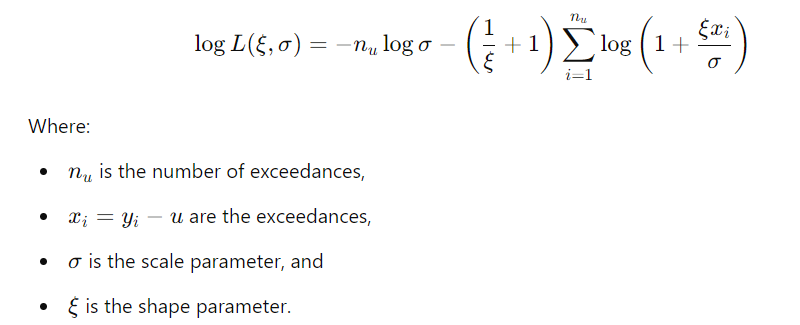

In [ ]:
np.set_printoptions(suppress=True)

In [ ]:
tu=0.95
tu

0.95

In [ ]:
n = len(data)
n

251

In [ ]:
u = sorted(data)[int(n * tu)]
u

0.05149462971654195

In [ ]:
values = (data.loc[data >= u]-u).values
values

array([0.01697268, 0.027348  , 0.00056073, 0.01708835, 0.0356261 ,
       0.01149627, 0.00623992, 0.        , 0.00993296, 0.00863403,
       0.01072238, 0.07733473, 0.00369825])

In [ ]:
tu = 0.95
n = len(data)
u = sorted(data)[int(n * tu)]
values = (data.loc[data >= u]-u).values
n_u = len(values)

def log_likelihood(param):
    log_l = -n_u*np.log(param[1]) - (1/param[0] + 1 )*sum([ np.log( 1 + (param[0]/param[1])*i) for i in values ])
    return -log_l

bounds_param = ((0+1e-6,None), (0+1e-6,None))
theta_start = (np.array(0), np.array(1))

opti_method = 'L-BFGS-B'
results = minimize(log_likelihood, theta_start, method=opti_method, bounds=bounds_param) #options={'maxiter': 300})#.x[0]
Beta = results.x[1]
Xi = results.x[0]

In [ ]:
print(f'Scale: {Beta}')
print(f'Shape: {Xi}')

Scale: 0.014608562090866013
Shape: 0.16128097577499056


## fit_mom: Method Of Moments

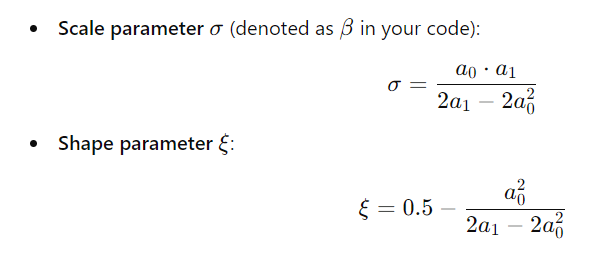

In [ ]:
a0 = values.mean()
a1 = sum([i**2 for i in values])/len(values)
Beta = (a0*a1)/(2*a1-2*a0**2)
Xi = 0.5-(a0**2/(2*a1-2*a0**2))

In [ ]:
print(f'Scale: {Beta}')
print(f'Shape: {Xi}')

Scale: 0.015300255083819724
Shape: 0.11854893073881112


## fit_pwm: Probability-Weighted Moments

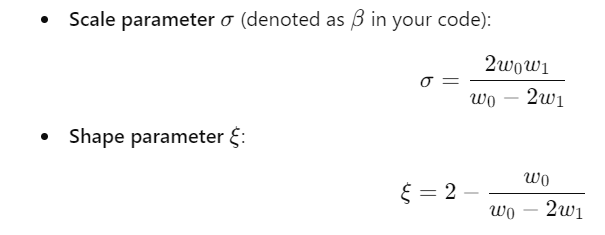

In [ ]:
w0 = values.mean()
w1 = sum([ (1- (sorted(values).index(x)-0.35)/len(values) )*x for x in sorted(values)])/len(values)
Beta = (2*w0*w1)/(w0-2*w1)
Xi = 2-(w0/(w0-2*w1))

In [ ]:
print(f'Scale: {Beta}')
print(f'Shape: {Xi}')

Scale: 0.025582362037676422
Shape: -0.4738055181957921


# Value at Risk y Expected Shortfall (Pérdida Esperada)

![var[1].png](https://i.sstatic.net/6y8My.png)

In [ ]:
fitted_gpd = gpd_pot(data, tu=0.95, fit="mle")

In [ ]:
# VaR de la pareto generalizada
fitted_gpd.varq(q=0.95)

0.05201073504331204

In [ ]:
# Conditional VaR o Caída Esperada
fitted_gpd.esq(q=0.95)

0.06952768605696721

# VaR y Expected Shortfall usuales (históricos), para comparación

In [ ]:
data.quantile(q=0.95)

0.049779791647648786

In [ ]:
data[data > data.quantile(q=0.95)].mean()

0.06885266082840392

# Aplicación:

Primero, definimos la "mean excess function"

In [ ]:
nb_sep = 100 # Cuantos threswholds
list_tu = [0.2*(i/nb_sep) for i in range(1,nb_sep)] # valores de 0 a 0.2
list_tu

[0.002,
 0.004,
 0.006,
 0.008,
 0.010000000000000002,
 0.012,
 0.014000000000000002,
 0.016,
 0.018,
 0.020000000000000004,
 0.022000000000000002,
 0.024,
 0.026000000000000002,
 0.028000000000000004,
 0.03,
 0.032,
 0.034,
 0.036,
 0.038000000000000006,
 0.04000000000000001,
 0.042,
 0.044000000000000004,
 0.046000000000000006,
 0.048,
 0.05,
 0.052000000000000005,
 0.054000000000000006,
 0.05600000000000001,
 0.057999999999999996,
 0.06,
 0.062,
 0.064,
 0.066,
 0.068,
 0.06999999999999999,
 0.072,
 0.074,
 0.07600000000000001,
 0.07800000000000001,
 0.08000000000000002,
 0.082,
 0.084,
 0.08600000000000001,
 0.08800000000000001,
 0.09000000000000001,
 0.09200000000000001,
 0.094,
 0.096,
 0.098,
 0.1,
 0.10200000000000001,
 0.10400000000000001,
 0.10600000000000001,
 0.10800000000000001,
 0.11000000000000001,
 0.11200000000000002,
 0.11399999999999999,
 0.11599999999999999,
 0.118,
 0.12,
 0.122,
 0.124,
 0.126,
 0.128,
 0.13,
 0.132,
 0.134,
 0.136,
 0.13799999999999998,
 0.139999

In [ ]:
def mean_exc(data):
    nb_sep = 100 # Cuantos threswholds
    list_tu = [0.2*(i/nb_sep) for i in range(1,nb_sep)] # valores de 0 a 0.2
    mean_exc, conf_low, conf_high = [], [], []

    for tu_ in list_tu:
        u = sorted(data)[int(len(data) * (1-tu_))]
        values = ((data.loc[data >= u])).values
        mean_ = values.mean()-u
        std_ = values.std()
        mean_exc.append(mean_)
        conf_low.append(mean_-std_)
        conf_high.append(mean_+std_)

    plt.plot(list_tu, mean_exc, 'o', color='red')
    plt.fill_between(list_tu, conf_low, conf_high, alpha = 0.4)
    plt.show()

[*********************100%***********************]  2 of 2 completed


Resultados con MLE: 
Scale: 0.010374141477806327 
Shape: 0.6004358484668343
Resultados con MOM: 
Scale: 0.016852204919517857 
Shape: 0.1639736993883451
Resultados con PWM: 
Scale: 0.02576802087900938 
Shape: -0.27833380097412386
0.06688462590039224


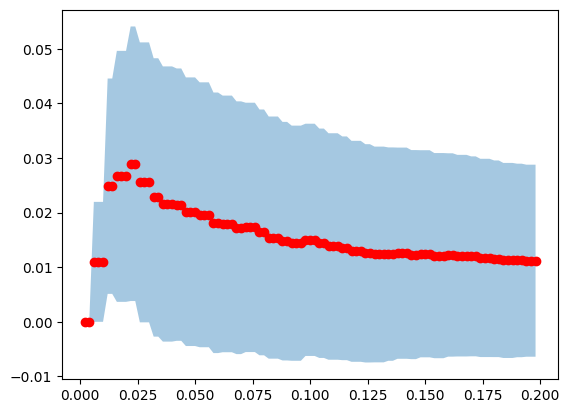

In [ ]:
df = yf.download(
        tickers = ["BTC-USD", 'GOOGL'],
        period = "1y",
        interval = "1d",
    ).loc[:, 'Adj Close']

for col in df.columns.values:
    df[col] = np.log(df[col]) - np.log(df[col].shift(1))
df = df.dropna()

data = -df["GOOGL"]
#US	UK	Switzerland	Sweden	Spain	Singapore	Norway	Netherlands	Japan	Italy

fitted_gpd = gpd_pot(data, tu=0.95, fit="mle")
print(f'Resultados con MLE: \nScale: {fitted_gpd.Beta} \nShape: {fitted_gpd.Xi}')

fitted_gpd = gpd_pot(data, tu=0.95, fit="mom")
print(f'Resultados con MOM: \nScale: {fitted_gpd.Beta} \nShape: {fitted_gpd.Xi}')

fitted_gpd = gpd_pot(data, tu=0.95, fit="pwm")
print(f'Resultados con PWM: \nScale: {fitted_gpd.Beta} \nShape: {fitted_gpd.Xi}')

print(fitted_gpd.quantile(q=0.99))

mean_exc(data)


# Como se vería la función de distribución para casos extremos

Modela la probabilidad de excederse de un cierto umbral

In [ ]:
fitted_gpd = gpd_pot(data, tu=0.95, fit="mle")

In [ ]:
fitted_gpd.Xi

0.6004358484668343

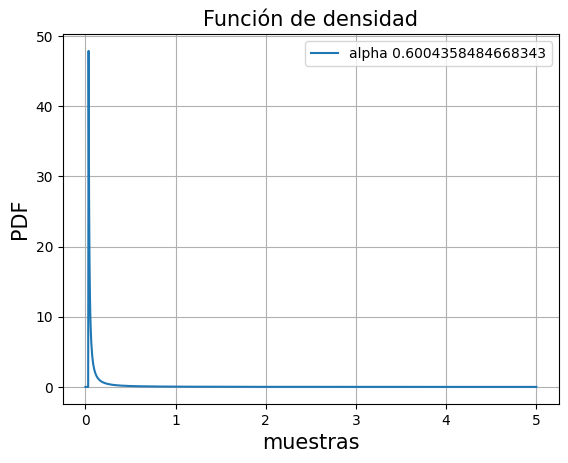

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import pareto
x_m = fitted_gpd.Beta #scale
alpha = [fitted_gpd.Xi] #shape parameters
samples = np.linspace(start=0, stop=5, num=1000)
for a in alpha:
    output = np.array([pareto.pdf(x=samples, b=a, loc=fitted_gpd.u, scale=x_m)])
    plt.plot(samples, output.T, label='alpha {0}' .format(a))
plt.xlabel('muestras', fontsize=15)
plt.ylabel('PDF', fontsize=15)
plt.title('Función de densidad', fontsize=15)
plt.grid()
plt.rcParams["figure.figsize"] = [5, 5]
plt.legend(loc='best')
plt.show()

## Hay resultados bastante distintos, ¿como podemos escoger el mejor modelo?

EJERCICIO: Cuando se define la clase al inicio del código (clase gpd_pot), hay dos métodos llamados qq_plot y pp_plot, ¿Los recuerdan? ¿Como podrían ayudarnos?

In [ ]:
# Espacio para ejercicio
df = yf.download(
        tickers = ["BTC-USD", 'GOOGL'],
        period = "1y",
        interval = "1d",
    ).loc[:, 'Adj Close']

for col in df.columns.values:
    df[col] = np.log(df[col]) - np.log(df[col].shift(1))
df = df.dropna()

data = -df["BTC-USD"]

[*********************100%***********************]  2 of 2 completed


Primer modelo: MLE

In [ ]:
fitted_gpd1 = gpd_pot(data, tu=0.95, fit="mle")
print(f'Resultados con MLE: \nScale: {fitted_gpd.Beta} \nShape: {fitted_gpd.Xi}')

Resultados con MLE: 
Scale: 0.015260252642225696 
Shape: 1e-06


<ipython-input-2-a1b9bb11ecc1>:52: RuntimeWarning: divide by zero encountered in scalar power
  return  (self.Beta/self.Xi)*( ((1-q) )**(-self.Xi) -1  )


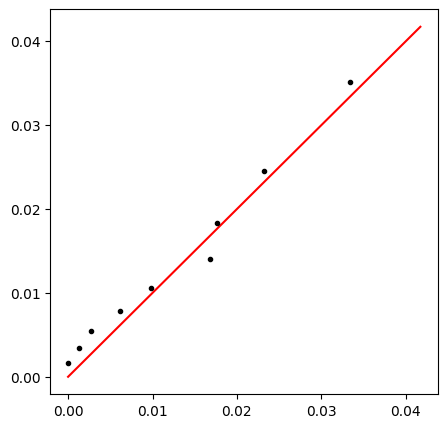

In [ ]:
fitted_gpd1.qq_plot()

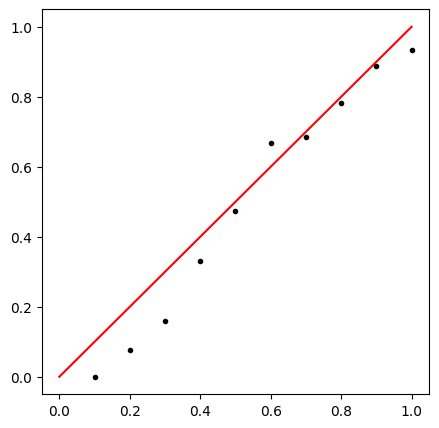

In [ ]:
fitted_gpd1.pp_plot()

In [ ]:
fitted_gpd2 = gpd_pot(data, tu=0.95, fit="mom")
print(f'Resultados con MOM: \nScale: {fitted_gpd.Beta} \nShape: {fitted_gpd.Xi}')

In [ ]:
fitted_gpd3 = gpd_pot(data, tu=0.95, fit="pwm")
print(f'Resultados con PWM: \nScale: {fitted_gpd.Beta} \nShape: {fitted_gpd.Xi}')

Paper intro: https://arxiv.org/pdf/1509.01051

code: https://github.com/maximenc/Extreme-Risk/tree/master

